In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk

In [107]:
df=pd.DataFrame(pd.read_csv("~/Downloads/Bengaluru_House_Data.csv"))
display(df.head())
display(df.tail())

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.0
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.0
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.0
13319,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,NaN,550,1.0,1.0,17.0


In [108]:
display(df.shape)
display(df.describe())

(13320, 9)

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [109]:
df.groupby('area_type')['area_type'].aggregate('count')

area_type
Built-up  Area          2418
Carpet  Area              87
Plot  Area              2025
Super built-up  Area    8790
Name: area_type, dtype: int64

In [110]:
data1=df[['area_type','location','size','total_sqft','bath','balcony','price']].copy()
data1.head()

,area_type,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Plot Area,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Built-up Area,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Super built-up Area,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Super built-up Area,Kothanur,2 BHK,1200,2.0,1.0,51.00


In [111]:
display(data1.isnull().sum())
data2=data1.dropna()
display(data2.isnull().sum())
data2.shape

area_type       0
location        1
size           16
total_sqft      0
bath           73
balcony       609
price           0
dtype: int64

area_type     0
location      0
size          0
total_sqft    0
bath          0
balcony       0
price         0
dtype: int64

(12710, 7)

In [112]:
display(data2['size'].unique())
data2['size']=data2['size'].apply(lambda x: x.split()[0])

<StringArray>
[     '2 BHK',  '4 Bedroom',      '3 BHK',  '3 Bedroom',      '1 BHK',
       '1 RK',      '4 BHK',  '1 Bedroom',  '2 Bedroom',  '6 Bedroom',
  '8 Bedroom',  '7 Bedroom',      '5 BHK',      '7 BHK',      '6 BHK',
  '5 Bedroom',     '11 BHK',      '9 BHK',  '9 Bedroom',     '27 BHK',
 '11 Bedroom', '43 Bedroom',     '14 BHK',      '8 BHK', '12 Bedroom',
 '10 Bedroom',     '13 BHK']
Length: 27, dtype: str

In [113]:
display(data2['size'].unique())
data2.rename(columns={'size':'bhk'}, inplace=True)
data2.head()

<StringArray>
[ '2',  '4',  '3',  '1',  '6',  '8',  '7',  '5', '11',  '9', '27', '43', '14',
 '12', '10', '13']
Length: 16, dtype: str

,area_type,location,bhk,total_sqft,bath,balcony,price
0,Super built-up Area,Electronic City Phase II,2,1056,2.0,1.0,39.07
1,Plot Area,Chikka Tirupathi,4,2600,5.0,3.0,120.00
2,Built-up Area,Uttarahalli,3,1440,2.0,3.0,62.00
3,Super built-up Area,Lingadheeranahalli,3,1521,3.0,1.0,95.00
4,Super built-up Area,Kothanur,2,1200,2.0,1.0,51.00


In [114]:
data2['total_sqft']=data2['total_sqft'].where(data2['total_sqft'].str.isdigit())
data2=data2.dropna()
display(data2.head())
data2.shape

,area_type,location,bhk,total_sqft,bath,balcony,price
0,Super built-up Area,Electronic City Phase II,2,1056,2.0,1.0,39.07
1,Plot Area,Chikka Tirupathi,4,2600,5.0,3.0,120.00
2,Built-up Area,Uttarahalli,3,1440,2.0,3.0,62.00
3,Super built-up Area,Lingadheeranahalli,3,1521,3.0,1.0,95.00
4,Super built-up Area,Kothanur,2,1200,2.0,1.0,51.00


(12438, 7)

In [115]:
data2['price']=data2['price'].astype(float)
data2['total_sqft']=data2['total_sqft'].astype(float)
data2['bhk']=data2['bhk'].astype(int)
data2['bath']=data2['bath'].astype(int)
data2['balcony']=data2['balcony'].astype(int)
data2.head()

,area_type,location,bhk,total_sqft,bath,balcony,price
0,Super built-up Area,Electronic City Phase II,2,1056.0,2,1,39.07
1,Plot Area,Chikka Tirupathi,4,2600.0,5,3,120.00
2,Built-up Area,Uttarahalli,3,1440.0,2,3,62.00
3,Super built-up Area,Lingadheeranahalli,3,1521.0,3,1,95.00
4,Super built-up Area,Kothanur,2,1200.0,2,1,51.00


In [116]:
data2['price_per_sqft']=data2['price']*100000/data2['total_sqft']
data2.head()

,area_type,location,bhk,total_sqft,bath,balcony,price,price_per_sqft
0,Super built-up Area,Electronic City Phase II,2,1056.0,2,1,39.07,3699.810606
1,Plot Area,Chikka Tirupathi,4,2600.0,5,3,120.00,4615.384615
2,Built-up Area,Uttarahalli,3,1440.0,2,3,62.00,4305.555556
3,Super built-up Area,Lingadheeranahalli,3,1521.0,3,1,95.00,6245.890861
4,Super built-up Area,Kothanur,2,1200.0,2,1,51.00,4250.000000


In [117]:
data2['location']=data2['location'].apply(lambda a: a.strip())
len(data2['location'].unique())

1246

In [118]:
locations=data2.groupby('location')['location'].agg('count').sort_values(ascending=False)
display(locations)

location
Whitefield                      499
Sarjapur  Road                  365
Electronic City                 302
Kanakpura Road                  250
Thanisandra                     222
                               ... 
2nd phase jp nagar, jp nagar      1
1 Giri Nagar                      1
1st Stage Domlur                  1
vinayakanagar                     1
t.c palya                         1
Name: location, Length: 1246, dtype: int64

In [119]:
display(len(locations[locations<7]))
locations_less7 = locations[locations<7]
locations_less7

924

location
1st Block HRBR Layout           6
Maragondanahalli                6
Yemlur                          6
Motappa Layout                  6
Nayandanahalli                  6
                               ..
2nd phase jp nagar, jp nagar    1
1 Giri Nagar                    1
1st Stage Domlur                1
vinayakanagar                   1
t.c palya                       1
Name: location, Length: 924, dtype: int64

In [120]:
data2['location']=data2['location'].apply(lambda x: 'Others' if x in locations_less7 else x)
pd.DataFrame(data2.head())

,area_type,location,bhk,total_sqft,bath,balcony,price,price_per_sqft
0,Super built-up Area,Electronic City Phase II,2,1056.0,2,1,39.07,3699.810606
1,Plot Area,Chikka Tirupathi,4,2600.0,5,3,120.00,4615.384615
2,Built-up Area,Uttarahalli,3,1440.0,2,3,62.00,4305.555556
3,Super built-up Area,Lingadheeranahalli,3,1521.0,3,1,95.00,6245.890861
4,Super built-up Area,Kothanur,2,1200.0,2,1,51.00,4250.000000


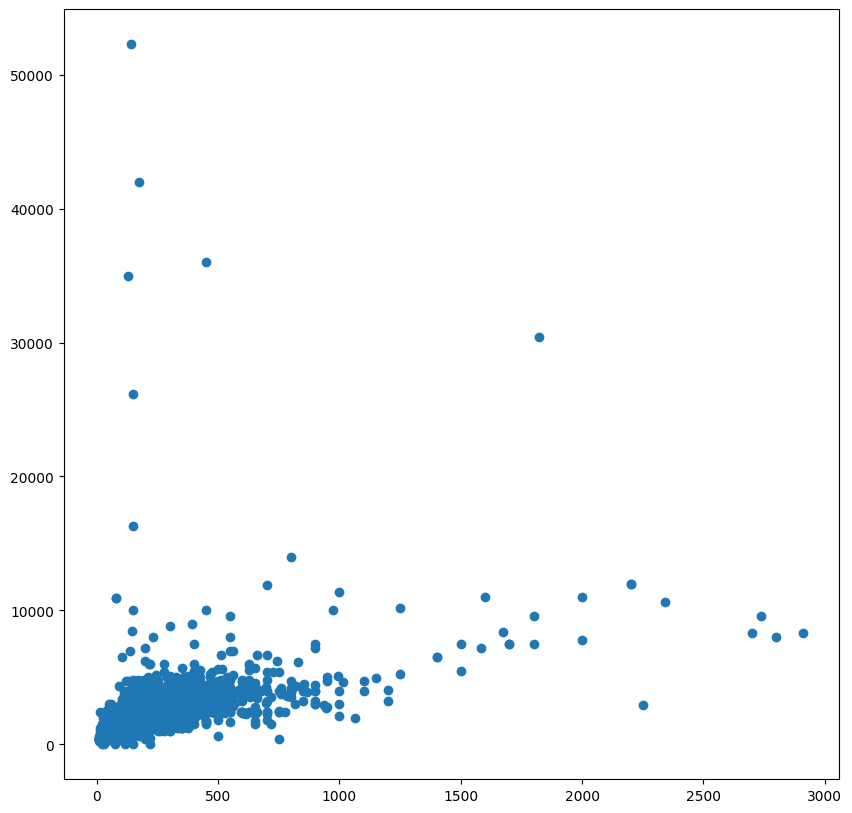

In [121]:
plt.scatter(data2['price'], data2['total_sqft'])

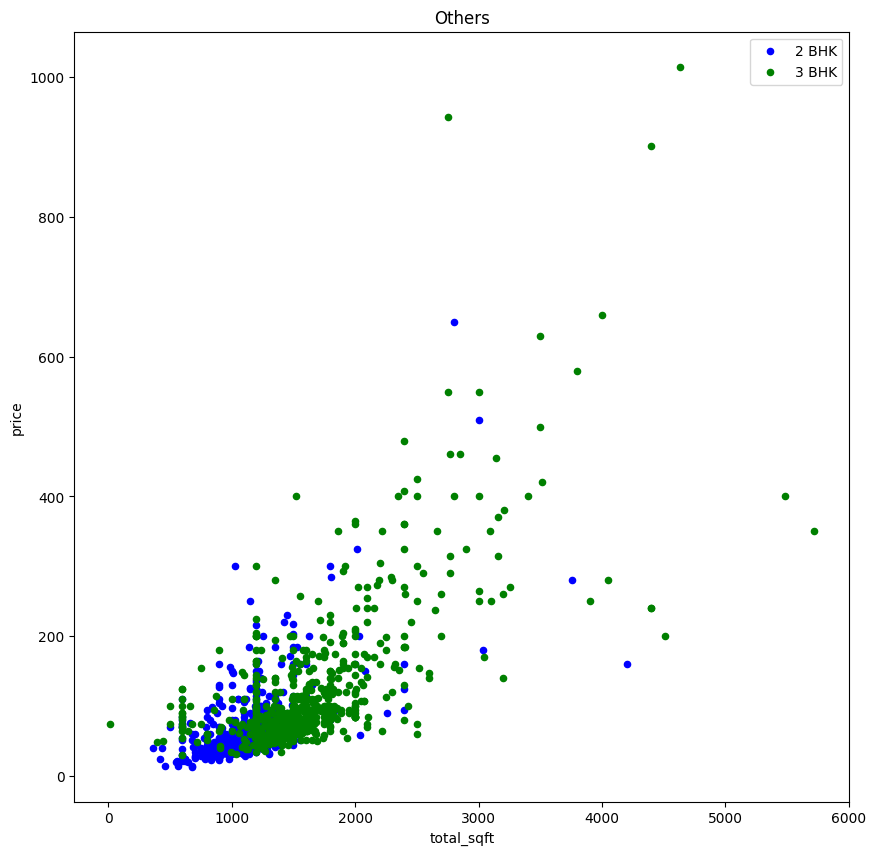

In [122]:
def scatter_plot(df,location):
    bhk2 = df[(df.location == location) & (df.bhk == 2)]
    bhk3 = df[(df.location == location) & (df.bhk == 3)]
    plt.rcParams["figure.figsize"] = (10,10)
    plt.scatter(bhk2.total_sqft, bhk2.price, color='blue', label = '2 BHK', s=20)
    plt.scatter(bhk3.total_sqft, bhk3.price, color='green', label = '3 BHK', s=20)
    plt.xlabel("total_sqft")
    plt.ylabel("price")
    plt.title(location)
    plt.legend()
    
scatter_plot(data2, "Others")

In [123]:
display(data2[data2.bath>data2.bhk+2])
data=data2[data2.bath<data2.bhk+2]
data.head(3)

,area_type,location,bhk,total_sqft,bath,balcony,price,price_per_sqft
1979,Plot Area,Hongasandra,8,990.0,12,0,120.0,12121.212121
2620,Super built-up Area,Sathya Sai Layout,6,11338.0,9,1,1000.0,8819.897689
6838,Super built-up Area,Rajaji Nagar,5,7500.0,8,3,1700.0,22666.666667
7709,Built-up Area,Chikkabanavar,4,2460.0,7,2,80.0,3252.032520
9974,Plot Area,Sector 1 HSR Layout,3,2400.0,6,2,775.0,32291.666667
9990,Plot Area,Others,6,1200.0,9,3,122.0,10166.666667
11645,Plot Area,Chamrajpet,6,1500.0,9,3,230.0,15333.333333
12103,Super built-up Area,Thanisandra,3,1806.0,6,2,116.0,6423.034330


,area_type,location,bhk,total_sqft,bath,balcony,price,price_per_sqft
0,Super built-up Area,Electronic City Phase II,2,1056.0,2,1,39.07,3699.810606
1,Plot Area,Chikka Tirupathi,4,2600.0,5,3,120.00,4615.384615
2,Built-up Area,Uttarahalli,3,1440.0,2,3,62.00,4305.555556


In [124]:
data=data.drop(['area_type','balcony','price_per_sqft'], axis=1)

In [125]:
data.head()

,location,bhk,total_sqft,bath,price
0,Electronic City Phase II,2,1056.0,2,39.07
1,Chikka Tirupathi,4,2600.0,5,120.00
2,Uttarahalli,3,1440.0,2,62.00
3,Lingadheeranahalli,3,1521.0,3,95.00
4,Kothanur,2,1200.0,2,51.00


In [126]:
dummies= pd.get_dummies(data.location)
dummies.head(3)

,1st Block Jayanagar,1st Block Koramangala,1st Phase JP Nagar,2nd Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,3rd Block Hrbr Layout,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,...,Vishwanatha Nagenahalli,Vishwapriya Layout,Vittasandra,Volagerekallahalli,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [127]:
data = pd.concat([data, dummies.drop('Others', axis=1)], axis=1)
data.head(3)

,location,bhk,total_sqft,bath,price,1st Block Jayanagar,1st Block Koramangala,1st Phase JP Nagar,2nd Phase JP Nagar,2nd Phase Judicial Layout,...,Vishwanatha Nagenahalli,Vishwapriya Layout,Vittasandra,Volagerekallahalli,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,Electronic City Phase II,2,1056.0,2,39.07,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,Chikka Tirupathi,4,2600.0,5,120.00,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,Uttarahalli,3,1440.0,2,62.00,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [128]:
data=data.drop('location', axis=1)
data.head(3)

,bhk,total_sqft,bath,price,1st Block Jayanagar,1st Block Koramangala,1st Phase JP Nagar,2nd Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,...,Vishwanatha Nagenahalli,Vishwapriya Layout,Vittasandra,Volagerekallahalli,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2,1056.0,2,39.07,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,4,2600.0,5,120.00,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,1440.0,2,62.00,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [129]:
X=data.drop('price', axis=1)
y=data.price

In [130]:
X_train, X_test, y_train, y_test= sk.model_selection.train_test_split(X,y,random_state=77, test_size=0.2)

In [138]:
pipe = sk.pipeline.make_pipeline(sk.preprocessing.QuantileTransformer(n_quantiles=5000,random_state=77), sk.neighbors.KNeighborsRegressor())

In [139]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('quantiletransformer', ...), ('kneighborsregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_quantiles n_quantiles: int, default=1000 or n_samplesNumber of quantiles to be computed. It corresponds to the numberof landmarks used to discretize the cumulative distribution function.If n_quantiles is larger than the number of samples, n_quantiles is setto the number of samples as a larger number of quantiles does not givea better approximation of the cumulative distribution functionestimator.",5000
,"output_distribution output_distribution: {'uniform', 'normal'}, default='uniform'Marginal distribution for the transformed data. The choices are'uniform' (default) or 'normal'.",'uniform'
,"ignore_implicit_zeros ignore_implicit_zeros: bool, default=FalseOnly applies to sparse matrices. If True, the sparse entries of thematrix are discarded to compute the quantile statistics. If False,these entries are treated as zeros.",False
,"subsample subsample: int or None, default=10_000Maximum number of samples used to estimate the quantiles forcomputational efficiency. Note that the subsampling procedure maydiffer for value-identical sparse and dense matrices.Disable subsampling by setting `subsample=None`... versionadded:: 1.5 The option `None` to disable subsampling was added.",10000
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for subsampling and smoothingnoise.Please see ``subsample`` for more details.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",77
,"copy copy: bool, default=TrueSet to False to perform inplace transformation and avoid a copy (if theinput is already a numpy array).",True
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5


In [141]:
pipe.score(X_test, y_test)

0.44222697541056866